# Caption Quality Evaluation (FashionStyle14 LLaVA Captions)

## Objective
This notebook evaluates **LLaVA-generated captions** in `FashionStyle14_v1/caption/fashion_captions_llava_success.csv` using eight caption-quality metrics. Each metric runs on the **test split** of stratified train/val/test partitions defined by robustness seeds in `seeds_list.txt`.

## Metrics (summary)
| Metric | What it measures | Better |
|--------|------------------|--------|
| CLIP Similarity | Global image-caption semantic alignment (cosine) | Higher |
| CLIP-IQA | Correct caption vs random captions (relative margin) | Higher |
| BLIPScore | BLIP image-text matching (ITM) | Higher |
| Retrieval Recall@K | Image/text cross-retrieval in embedding space | Higher |
| Confusion Matrix | Style prediction from image+caption vs ground truth | Lower off-diagonal |
| GPT-4o Evaluation | LLM judgment of correctness and style fit | Higher |
| Random Caption Sanity | Accuracy drop when captions are shuffled | Larger drop |
| Class-Randomized Sanity | Accuracy drop when captions come from other styles | Larger drop |

## Configuration
- Set `USE_ALL_SEEDS = False` and `NUM_SEEDS_TO_USE = 10` to run the **first 10** seeds (default, matches other notebooks).
- Set `USE_ALL_SEEDS = True` to run **all 30** seeds from `seeds_list.txt`.
- Optional `MAX_SAMPLES_PER_EVAL` subsamples the test set per seed for faster debugging.

## Inputs
| Path | Role |
|------|------|
| `FashionStyle14_v1/complete_dataset.csv` | Image list |
| `FashionStyle14_v1/caption/fashion_captions_llava_success.csv` | Captions |
| `FashionStyle14_v1/seeds_list.txt` | Split seeds |
| `FashionStyle14_v1/dataset/` | Image files |

## Outputs
All artifacts are written under **`results/caption_evaluation/<metric_name>/`**:
- Per-seed CSV/JSON scores
- `all_seeds_summary.csv` (one row per seed)
- Figures (PNG) where applicable
- Printed **mean +/- std** after each metric section

Code, comments, and plots use **English only**.


## 1. Configuration, imports, and paths


In [1]:
from __future__ import annotations

import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModel,
    AutoTokenizer,
    BlipForImageTextRetrieval,
    BlipProcessor,
    CLIPModel,
    CLIPProcessor,
)

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# --- Seed scope ---
USE_ALL_SEEDS = True
NUM_SEEDS_TO_USE = 30

# --- Evaluation scope ---
MAX_SAMPLES_PER_EVAL: Optional[int] = None  # e.g. 200 for quick runs; None = full test set
EVAL_BATCH_SIZE = 32
RETRIEVAL_K_VALUES = [1, 5, 10]
OVERWRITE_EXISTING = False
RANDOM_CAPTION_SANITY_SEED = 42
CLASS_RANDOM_SANITY_SEED = 43

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BLIP_ITM_MODEL_ID = "Salesforce/blip-itm-base-coco"
BERT_MODEL_ID = "bert-base-uncased"

SANITY_TRAIN_EPOCHS = 8
SANITY_BATCH_SIZE = 16
SANITY_LR = 5e-4
SANITY_DROPOUT = 0.5

GPT4O_MODEL = "gpt-4o"
GPT4O_MAX_SAMPLES_PER_SEED = 50
SKIP_GPT4O_IF_NO_KEY = True

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


def load_seeds(seeds_file: Path) -> List[int]:
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds in file, found {len(seeds)}")
    return seeds


DATA_DIR = Path("./FashionStyle14_v1")
RESULTS_ROOT = Path("./robustness/caption_evaluation")
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
CAPTION_CSV = DATA_DIR / "caption" / "fashion_captions_llava_success.csv"

ALL_PARSED_SEEDS = load_seeds(SEEDS_FILE)
SEEDS = ALL_PARSED_SEEDS if USE_ALL_SEEDS else ALL_PARSED_SEEDS[:NUM_SEEDS_TO_USE]
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("CAPTION_CSV:", CAPTION_CSV)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"Seed mode: {'ALL' if USE_ALL_SEEDS else f'FIRST {NUM_SEEDS_TO_USE}'} -> {len(SEEDS)} seeds")
print("SEEDS:", SEEDS)

c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA_DIR: FashionStyle14_v1
CAPTION_CSV: FashionStyle14_v1\caption\fashion_captions_llava_success.csv
RESULTS_ROOT: robustness\caption_evaluation
Seed mode: ALL -> 30 seeds
SEEDS: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]


## 2. Hardware and device


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    if total_mem_gb < 8:
        EVAL_BATCH_SIZE = min(EVAL_BATCH_SIZE, 16)
        SANITY_BATCH_SIZE = min(SANITY_BATCH_SIZE, 8)
else:
    print("CUDA not available; using CPU (slower).")
    EVAL_BATCH_SIZE = min(EVAL_BATCH_SIZE, 8)
    SANITY_BATCH_SIZE = min(SANITY_BATCH_SIZE, 8)

print("device:", device)
print("EVAL_BATCH_SIZE:", EVAL_BATCH_SIZE)
print("SANITY_BATCH_SIZE:", SANITY_BATCH_SIZE)
print("use_amp:", use_amp)

CUDA device: NVIDIA GeForce RTX 3060 Ti
Total GPU memory: 8.00 GB
device: cuda
EVAL_BATCH_SIZE: 16
SANITY_BATCH_SIZE: 8
use_amp: True


## 3. Load dataset, captions, and split helpers


In [3]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def canonical_merge_key(raw: str) -> str:
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()
    if low.startswith("fashionstyle14_v1/"):
        s = s[len("fashionstyle14_v1/") :].lstrip("/")
        low = s.lower()
    marker = "dataset/"
    ix = low.find(marker)
    if ix >= 0:
        return normalize_rel_path(s[ix:])
    if low.startswith("/dataset/"):
        return normalize_rel_path(s.lstrip("/"))
    return s


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(canonical_merge_key)
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str(IMAGE_ROOT / r.replace("/", os.sep)))
    return df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)


def load_captions_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    work = df.copy()
    if "status" in work.columns:
        work = work[work["status"].astype(str).str.lower() == "success"]
    path_col = next((c for c in work.columns if c.lower().strip() in {"image_path", "rel_path", "path"}), None)
    cap_col = next((c for c in work.columns if c.lower().strip() in {"caption", "text", "description"}), None)
    if path_col is None or cap_col is None:
        raise ValueError(f"Caption CSV columns invalid: {list(work.columns)}")
    out = work[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(canonical_merge_key)
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    out = out[out["caption"] != ""].drop_duplicates(subset=["merge_key"], keep="last")
    return out.reset_index(drop=True)


df_paths = load_complete_dataset(COMPLETE_CSV)
cap_df = load_captions_long(CAPTION_CSV)
df_full = df_paths.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}"
style_to_idx = {s: i for i, s in enumerate(classes)}
idx_to_style = {i: s for s, i in style_to_idx.items()}
num_classes = len(classes)

print("Samples with captions:", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print("Example data:")
print(df_full.head())


def split_by_seed(df: pd.DataFrame, seed_value: int):
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def subsample_test_df(test_df: pd.DataFrame) -> pd.DataFrame:
    if MAX_SAMPLES_PER_EVAL is None or len(test_df) <= MAX_SAMPLES_PER_EVAL:
        return test_df
    return test_df.sample(n=MAX_SAMPLES_PER_EVAL, random_state=42).reset_index(drop=True)


def metric_dir(name: str) -> Path:
    p = RESULTS_ROOT / name
    p.mkdir(parents=True, exist_ok=True)
    return p


def print_mean_std_table(df: pd.DataFrame, value_cols: List[str], title: str) -> pd.DataFrame:
    rows = []
    print(f"\n=== {title}: mean +/- std across seeds ===")
    for col in value_cols:
        if col not in df.columns:
            continue
        vals = df[col].astype(float).dropna()
        mean_v, std_v = float(vals.mean()), float(vals.std(ddof=0))
        rows.append({"metric": col, "mean": mean_v, "std": std_v})
        print(f"  {col}: {mean_v:.4f} +/- {std_v:.4f}  (n={len(vals)})")
    summary = pd.DataFrame(rows)
    return summary


def save_summary_csv(summary: pd.DataFrame, out_path: Path) -> None:
    summary.to_csv(out_path, index=False)
    print("Saved summary:", out_path)


@torch.no_grad()
def load_pil_batch(paths: List[str]) -> List[Image.Image]:
    return [Image.open(p).convert("RGB") for p in paths]


print("Data helpers ready.")

Samples with captions: 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Example data:
                                    rel_path  \
0    dataset/conservative/conservative_1.jpg   
1   dataset/conservative/conservative_10.jpg   
2  dataset/conservative/conservative_100.jpg   
3  dataset/conservative/conservative_101.jpg   
4  dataset/conservative/conservative_102.jpg   

                                   merge_key         style  \
0    dataset/conservative/conservative_1.jpg  conservative   
1   dataset/conservative/conservative_10.jpg  conservative   
2  dataset/conservative/conservative_100.jpg  conservative   
3  dataset/conservative/conservative_101.jpg  conservative   
4  dataset/conservative/conservative_102.jpg  conservative   

                                            abs_path  \
0  FashionStyle14_v1\dataset\conservative\conserv...   
1 

## 4. Evaluation Metrics

### CLIP Similarity

Image + Caption -> CLIP embeddings -> cosine similarity. **Higher is better.**


In [4]:
def clip_cosine_similarity_batch(clip_model, clip_processor, paths, captions, device, batch_size):
    scores = []
    clip_model.eval()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_caps = captions[i : i + batch_size]
        images = load_pil_batch(batch_paths)
        inputs = clip_processor(text=batch_caps, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        txt_emb = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
        sim = (img_emb * txt_emb).sum(dim=-1).detach().cpu().numpy()
        scores.extend(sim.tolist())
    return np.array(scores, dtype=np.float32)


def run_clip_similarity_for_seeds():
    out_dir = metric_dir("clip_similarity")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        print("Loading existing:", summary_path)
        return pd.read_csv(summary_path)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
            mean_sim = float(per_seed["clip_similarity"].mean())
        else:
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df)
            sims = clip_cosine_similarity_batch(
                clip_model, clip_processor, test_df["abs_path"].tolist(), test_df["caption"].tolist(), device, EVAL_BATCH_SIZE,
            )
            per_seed = test_df[["merge_key", "style", "rel_path"]].copy()
            per_seed["clip_similarity"] = sims
            per_seed.to_csv(seed_csv, index=False)
            mean_sim = float(np.mean(sims))
        print(f"[clip_similarity] {seed_tag} ({si}/{len(SEEDS)}): mean={mean_sim:.4f} n={len(per_seed)}")
        rows.append({"seed": seed, "clip_similarity_mean": mean_sim, "n_test": len(per_seed)})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["clip_similarity_mean"])
    ax.set_title("CLIP Similarity per seed")
    ax.set_ylabel("Mean cosine similarity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "clip_similarity_per_seed.png", dpi=150)
    plt.show()
    return summary_df

clip_similarity_summary = run_clip_similarity_for_seeds()
print(clip_similarity_summary)
save_summary_csv(
    print_mean_std_table(clip_similarity_summary, ["clip_similarity_mean"], "CLIP Similarity"),
    metric_dir("clip_similarity") / "aggregation_mean_std.csv",
)

Loading existing: robustness\caption_evaluation\clip_similarity\all_seeds_summary.csv
    seed  clip_similarity_mean  n_test
0     13              0.299811    1982
1     14              0.299781    1982
2     16              0.300112    1982
3     17              0.299262    1982
4     45              0.299416    1982
5     48              0.299889    1982
6     53              0.300102    1982
7     58              0.300976    1982
8     72              0.299258    1982
9    102              0.299688    1982
10   112              0.299820    1982
11   115              0.300130    1982
12   120              0.300861    1982
13   126              0.300354    1982
14   141              0.299798    1982
15   215              0.299739    1982
16   217              0.300312    1982
17   259              0.300367    1982
18   280              0.299463    1982
19   288              0.298990    1982
20   303              0.299503    1982
21   309              0.299403    1982
22   328         

### CLIP-IQA

Image + correct caption vs random captions. **Higher win rate and margin are better.**


In [5]:
def clip_cosine_similarity_batch(clip_model, clip_processor, paths, captions, device, batch_size):
    scores = []
    clip_model.eval()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_caps = captions[i : i + batch_size]
        images = load_pil_batch(batch_paths)
        inputs = clip_processor(text=batch_caps, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        txt_emb = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
        sim = (img_emb * txt_emb).sum(dim=-1).detach().cpu().numpy()
        scores.extend(sim.tolist())
    return np.array(scores, dtype=np.float32)


def run_clip_iqa_for_seeds(num_negatives: int = 5):
    out_dir = metric_dir("clip_iqa")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        _, _, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        n = len(test_df)
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
        else:
            rng = np.random.default_rng(seed)
            paths, all_caps = test_df["abs_path"].tolist(), test_df["caption"].tolist()
            pos_sims = clip_cosine_similarity_batch(clip_model, clip_processor, paths, all_caps, device, EVAL_BATCH_SIZE)
            margins, wins = [], []
            for i in range(n):
                neg_idx = rng.choice([j for j in range(n) if j != i], size=min(num_negatives, max(1, n - 1)), replace=False)
                neg_caps = [all_caps[j] for j in neg_idx]
                neg_sims = clip_cosine_similarity_batch(
                    clip_model, clip_processor, [paths[i]] * len(neg_caps), neg_caps, device, EVAL_BATCH_SIZE,
                )
                margins.append(float(pos_sims[i] - neg_sims.mean()))
                wins.append(1.0 if pos_sims[i] > neg_sims.max() else 0.0)
            per_seed = test_df[["merge_key", "style"]].copy()
            per_seed["clip_iqa_margin"] = margins
            per_seed["clip_iqa_win"] = wins
            per_seed.to_csv(seed_csv, index=False)
        win_rate = float(per_seed["clip_iqa_win"].mean())
        margin = float(per_seed["clip_iqa_margin"].mean())
        print(f"[clip_iqa] {seed_tag} ({si}/{len(SEEDS)}): win_rate={win_rate:.4f} margin={margin:.4f}")
        rows.append({"seed": seed, "clip_iqa_win_rate": win_rate, "clip_iqa_margin_mean": margin, "n_test": n})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(summary_df["seed"].astype(str), summary_df["clip_iqa_win_rate"])
    axes[0].set_title("CLIP-IQA win rate")
    axes[1].bar(summary_df["seed"].astype(str), summary_df["clip_iqa_margin_mean"])
    axes[1].set_title("CLIP-IQA margin")
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "clip_iqa_per_seed.png", dpi=150)
    plt.show()
    return summary_df

clip_iqa_summary = run_clip_iqa_for_seeds()
save_summary_csv(
    print_mean_std_table(clip_iqa_summary, ["clip_iqa_win_rate", "clip_iqa_margin_mean"], "CLIP-IQA"),
    metric_dir("clip_iqa") / "aggregation_mean_std.csv",
)



=== CLIP-IQA: mean +/- std across seeds ===
  clip_iqa_win_rate: 0.9375 +/- 0.0073  (n=30)
  clip_iqa_margin_mean: 0.0942 +/- 0.0007  (n=30)
Saved summary: robustness\caption_evaluation\clip_iqa\aggregation_mean_std.csv


### BLIPScore

Image + Caption -> BLIP ITM head matching score. **Higher is better.**


In [6]:
def blip_itm_scores_batch(blip_model, blip_processor, paths, captions, device, batch_size):
    scores = []
    blip_model.eval()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_caps = captions[i : i + batch_size]
        images = load_pil_batch(batch_paths)
        inputs = blip_processor(images=images, text=batch_caps, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = blip_model(**inputs, use_itm_head=True)
            # itm_head outputs (batch, 2) logits: negative / positive match
            logits = out.itm_score
            if logits.ndim == 1:
                batch_scores = logits
            else:
                batch_scores = torch.softmax(logits, dim=-1)[:, 1]
            scores.extend(batch_scores.detach().cpu().numpy().reshape(-1).tolist())
    return np.array(scores, dtype=np.float32)


def run_blipscore_for_seeds():
    out_dir = metric_dir("blipscore")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    blip_model = BlipForImageTextRetrieval.from_pretrained(BLIP_ITM_MODEL_ID).to(device)
    blip_processor = BlipProcessor.from_pretrained(BLIP_ITM_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
            mean_score = float(per_seed["blip_itm_score"].mean())
        else:
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df)
            sc = blip_itm_scores_batch(
                blip_model, blip_processor, test_df["abs_path"].tolist(), test_df["caption"].tolist(), device, EVAL_BATCH_SIZE,
            )
            per_seed = test_df[["merge_key", "style"]].copy()
            per_seed["blip_itm_score"] = sc
            per_seed.to_csv(seed_csv, index=False)
            mean_score = float(np.mean(sc))
        print(f"[blipscore] {seed_tag} ({si}/{len(SEEDS)}): mean_itm={mean_score:.4f}")
        rows.append({"seed": seed, "blip_itm_mean": mean_score, "n_test": len(per_seed)})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["blip_itm_mean"], color="coral")
    ax.set_title("BLIP ITM score per seed")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "blipscore_per_seed.png", dpi=150)
    plt.show()
    return summary_df

blip_summary = run_blipscore_for_seeds()
save_summary_csv(
    print_mean_std_table(blip_summary, ["blip_itm_mean"], "BLIPScore"),
    metric_dir("blipscore") / "aggregation_mean_std.csv",
)


=== BLIPScore: mean +/- std across seeds ===
  blip_itm_mean: 0.9194 +/- 0.0030  (n=30)
Saved summary: robustness\caption_evaluation\blipscore\aggregation_mean_std.csv


### Retrieval Recall@K

CLIP embeddings on the test set; image-to-text and text-to-image Recall@K. **Higher is better.**


In [7]:
def recall_at_k(sim_matrix: np.ndarray, k: int) -> float:
    n = sim_matrix.shape[0]
    hits = 0
    for i in range(n):
        order = np.argsort(-sim_matrix[i])
        topk = order[:k]
        if i in topk:
            hits += 1
    return hits / max(n, 1)


@torch.no_grad()
def clip_encode_images_texts(clip_model, clip_processor, paths, captions, device, batch_size):
    img_feats, txt_feats = [], []
    for i in range(0, len(paths), batch_size):
        bp, bc = paths[i : i + batch_size], captions[i : i + batch_size]
        images = load_pil_batch(bp)
        inputs = clip_processor(text=bc, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_feats.append(out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True))
        txt_feats.append(out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True))
    return torch.cat(img_feats, dim=0), torch.cat(txt_feats, dim=0)


def run_retrieval_for_seeds():
    out_dir = metric_dir("retrieval_recall")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        _, _, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        paths, caps = test_df["abs_path"].tolist(), test_df["caption"].tolist()
        img_e, txt_e = clip_encode_images_texts(clip_model, clip_processor, paths, caps, device, EVAL_BATCH_SIZE)
        sim_i2t = (img_e @ txt_e.T).cpu().numpy()
        sim_t2i = sim_i2t.T
        row = {"seed": seed, "n_test": len(test_df)}
        for k in RETRIEVAL_K_VALUES:
            row[f"i2t_recall@{k}"] = recall_at_k(sim_i2t, k)
            row[f"t2i_recall@{k}"] = recall_at_k(sim_t2i, k)
        print(f"[retrieval] {seed_tag} ({si}/{len(SEEDS)}):", {k: row[f"i2t_recall@{k}"] for k in RETRIEVAL_K_VALUES})
        rows.append(row)
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    for direction, prefix in [("Image-to-text", "i2t"), ("Text-to-image", "t2i")]:
        fig, ax = plt.subplots(figsize=(8, 4))
        for k in RETRIEVAL_K_VALUES:
            ax.plot(summary_df["seed"].astype(str), summary_df[f"{prefix}_recall@{k}"], marker="o", label=f"R@{k}")
        ax.set_title(f"{direction} retrieval per seed")
        ax.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(out_dir / f"{prefix}_recall_per_seed.png", dpi=150)
        plt.show()
    return summary_df

retrieval_summary = run_retrieval_for_seeds()
rec_cols = [f"i2t_recall@{k}" for k in RETRIEVAL_K_VALUES] + [f"t2i_recall@{k}" for k in RETRIEVAL_K_VALUES]
save_summary_csv(
    print_mean_std_table(retrieval_summary, rec_cols, "Retrieval Recall@K"),
    metric_dir("retrieval_recall") / "aggregation_mean_std.csv",
)


=== Retrieval Recall@K: mean +/- std across seeds ===
  i2t_recall@1: 0.2480 +/- 0.0089  (n=30)
  i2t_recall@5: 0.4957 +/- 0.0098  (n=30)
  i2t_recall@10: 0.6092 +/- 0.0099  (n=30)
  t2i_recall@1: 0.1990 +/- 0.0108  (n=30)
  t2i_recall@5: 0.4063 +/- 0.0139  (n=30)
  t2i_recall@10: 0.5142 +/- 0.0125  (n=30)
Saved summary: robustness\caption_evaluation\retrieval_recall\aggregation_mean_std.csv


### Confusion Matrix (CLIP zero-shot style from image+caption)

Fuse image and text CLIP embeddings; nearest style prompt is the prediction. **Lower off-diagonal confusion is better.**


In [8]:
STYLE_PROMPTS = [f"a fashion outfit in the {s} style" for s in classes]

@torch.no_grad()
def clip_zero_shot_predict(clip_model, clip_processor, paths, captions, device, batch_size):
    text_inputs = clip_processor(text=STYLE_PROMPTS, return_tensors="pt", padding=True)
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    text_emb = clip_model.get_text_features(**text_inputs)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    preds = []
    for i in range(0, len(paths), batch_size):
        bp, bc = paths[i : i + batch_size], captions[i : i + batch_size]
        images = load_pil_batch(bp)
        img_inputs = clip_processor(images=images, return_tensors="pt")
        img_inputs = {k: v.to(device) for k, v in img_inputs.items()}
        img_emb = clip_model.get_image_features(**img_inputs)
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        cap_inputs = clip_processor(text=bc, return_tensors="pt", padding=True, truncation=True)
        cap_inputs = {k: v.to(device) for k, v in cap_inputs.items()}
        cap_emb = clip_model.get_text_features(**cap_inputs)
        cap_emb = cap_emb / cap_emb.norm(dim=-1, keepdim=True)
        fused = (img_emb + cap_emb) / (img_emb + cap_emb).norm(dim=-1, keepdim=True)
        logits = fused @ text_emb.T
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
    return np.array(preds, dtype=int)


def run_confusion_matrix_for_seeds():
    out_dir = metric_dir("confusion_matrix")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        summary_df = pd.read_csv(summary_path)
    else:
        clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
        clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        rows = []
        agg_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
        for si, seed in enumerate(SEEDS, start=1):
            seed_tag = f"seed_{seed}"
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df).reset_index(drop=True)
            y_true = test_df["style"].map(style_to_idx).to_numpy()
            y_pred = clip_zero_shot_predict(
                clip_model, clip_processor, test_df["abs_path"].tolist(), test_df["caption"].tolist(), device, EVAL_BATCH_SIZE,
            )
            acc = accuracy_score(y_true, y_pred)
            macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
            cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
            agg_cm += cm
            per_seed = test_df[["merge_key", "style"]].copy()
            per_seed["pred_style"] = [idx_to_style[i] for i in y_pred]
            per_seed.to_csv(out_dir / f"{seed_tag}_predictions.csv", index=False)
            print(f"[confusion] {seed_tag} ({si}/{len(SEEDS)}): acc={acc:.4f} macro_f1={macro_f1:.4f}")
            rows.append({"seed": seed, "accuracy": acc, "macro_f1": macro_f1, "n_test": len(test_df)})
        summary_df = pd.DataFrame(rows)
        summary_df.to_csv(summary_path, index=False)
        np.save(out_dir / "aggregated_confusion_matrix.npy", agg_cm)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(agg_cm, xticklabels=classes, yticklabels=classes, annot=False, fmt="d", cmap="Blues", ax=ax)
        ax.set_xlabel("Predicted style")
        ax.set_ylabel("True style")
        ax.set_title("Aggregated confusion matrix (all seeds)")
        plt.tight_layout()
        plt.savefig(out_dir / "confusion_matrix_aggregated.png", dpi=150)
        plt.show()
        print("Saved aggregated confusion matrix.")
    return summary_df

confusion_summary = run_confusion_matrix_for_seeds()
print(confusion_summary)
save_summary_csv(
    print_mean_std_table(confusion_summary, ["accuracy", "macro_f1"], "Confusion / zero-shot style"),
    metric_dir("confusion_matrix") / "aggregation_mean_std.csv",
)

    seed  accuracy  macro_f1  n_test
0     13  0.271443  0.208306    1982
1     14  0.272452  0.211463    1982
2     16  0.272452  0.210486    1982
3     17  0.260343  0.204505    1982
4     45  0.270434  0.213115    1982
5     48  0.269929  0.214031    1982
6     53  0.270434  0.212538    1982
7     58  0.267407  0.205062    1982
8     72  0.271443  0.215472    1982
9    102  0.273966  0.211240    1982
10   112  0.275984  0.217625    1982
11   115  0.266902  0.203457    1982
12   120  0.272957  0.214893    1982
13   126  0.281029  0.220356    1982
14   141  0.275479  0.217971    1982
15   215  0.271443  0.214581    1982
16   217  0.267407  0.208912    1982
17   259  0.265893  0.206248    1982
18   280  0.273461  0.214251    1982
19   288  0.270434  0.210665    1982
20   303  0.274975  0.216890    1982
21   309  0.271948  0.214579    1982
22   328  0.275984  0.213968    1982
23   333  0.263370  0.205801    1982
24   347  0.270938  0.212908    1982
25   360  0.278002  0.217907    1982
2

### GPT-4o Evaluation

GPT-4o rates caption correctness and style consistency (1-5). Requires `OPENAI_API_KEY`. **Higher is better.**


In [9]:
from dotenv import load_dotenv
load_dotenv() 

True

In [10]:
def run_gpt4o_for_seeds():
    out_dir = metric_dir("gpt4o_evaluation")
    summary_path = out_dir / "all_seeds_summary.csv"
    api_key = os.environ.get("OPENAI_API_KEY", "").strip()
    if not api_key and SKIP_GPT4O_IF_NO_KEY:
        print("OPENAI_API_KEY not set; skipping GPT-4o evaluation.")
        return pd.DataFrame()
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    try:
        from openai import OpenAI
    except ImportError:
        print("Install openai package: pip install openai")
        return pd.DataFrame()
    import base64
    from io import BytesIO

    client = OpenAI(api_key=api_key)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
        else:
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df).reset_index(drop=True)
            if GPT4O_MAX_SAMPLES_PER_SEED and len(test_df) > GPT4O_MAX_SAMPLES_PER_SEED:
                test_df = test_df.sample(n=GPT4O_MAX_SAMPLES_PER_SEED, random_state=seed).reset_index(drop=True)
            scores_sem, scores_style = [], []
            records = []
            for _, row in test_df.iterrows():
                img = Image.open(row["abs_path"]).convert("RGB")
                img.thumbnail((512, 512))
                buf = BytesIO()
                img.save(buf, format="JPEG", quality=85)
                b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
                prompt = (
                    f"Ground-truth fashion style label: {row['style']}. "
                    f"Caption: {row['caption']} "
                    "Rate (1-5): semantic_correctness, style_consistency. "
                    'Reply JSON only: {"semantic_correctness": int, "style_consistency": int}'
                )
                try:
                    resp = client.chat.completions.create(
                        model=GPT4O_MODEL,
                        messages=[{
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
                            ],
                        }],
                        max_tokens=80,
                    )
                    text = resp.choices[0].message.content or "{}"
                    m = re.search(r"\{[^}]+\}", text)
                    parsed = json.loads(m.group(0)) if m else {}
                    s1 = float(parsed.get("semantic_correctness", np.nan))
                    s2 = float(parsed.get("style_consistency", np.nan))
                except Exception as exc:
                    print("GPT-4o error:", exc)
                    s1, s2 = np.nan, np.nan
                scores_sem.append(s1)
                scores_style.append(s2)
                records.append({"merge_key": row["merge_key"], "semantic": s1, "style_fit": s2})
            per_seed = pd.DataFrame(records)
            per_seed.to_csv(seed_csv, index=False)
        mean_sem = float(per_seed["semantic"].mean())
        mean_style = float(per_seed["style_fit"].mean())
        print(f"[gpt4o] {seed_tag} ({si}/{len(SEEDS)}): semantic={mean_sem:.3f} style={mean_style:.3f}")
        rows.append({"seed": seed, "gpt4o_semantic_mean": mean_sem, "gpt4o_style_mean": mean_style, "n_test": len(per_seed)})
    summary_df = pd.DataFrame(rows)
    if len(summary_df):
        summary_df.to_csv(summary_path, index=False)
        fig, ax = plt.subplots(figsize=(8, 4))
        x = np.arange(len(summary_df))
        w = 0.35
        ax.bar(x - w / 2, summary_df["gpt4o_semantic_mean"], width=w, label="semantic")
        ax.bar(x + w / 2, summary_df["gpt4o_style_mean"], width=w, label="style")
        ax.set_xticks(x)
        ax.set_xticklabels(summary_df["seed"].astype(str), rotation=45, ha="right")
        ax.legend()
        ax.set_title("GPT-4o scores per seed")
        plt.tight_layout()
        plt.savefig(out_dir / "gpt4o_per_seed.png", dpi=150)
        plt.show()
    return summary_df

gpt4o_summary = run_gpt4o_for_seeds()
if len(gpt4o_summary):
    save_summary_csv(
        print_mean_std_table(gpt4o_summary, ["gpt4o_semantic_mean", "gpt4o_style_mean"], "GPT-4o"),
        metric_dir("gpt4o_evaluation") / "aggregation_mean_std.csv",
    )


=== GPT-4o: mean +/- std across seeds ===
  gpt4o_semantic_mean: 4.0429 +/- 0.1224  (n=30)
  gpt4o_style_mean: 3.9447 +/- 0.1117  (n=30)
Saved summary: robustness\caption_evaluation\gpt4o_evaluation\aggregation_mean_std.csv


### Random Caption Sanity Check

Train frozen CLIP+BERT fusion classifier; compare test accuracy with correct vs shuffled captions. **Larger drop is better.**


In [11]:
class FusionRowDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, caption_col: str = "caption"):
        self.frame = frame.reset_index(drop=True)
        self.caption_col = caption_col

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return {"abs_path": row["abs_path"], "caption": str(row[self.caption_col]), "label": style_to_idx[row["style"]]}


class ClipBertFusionClassifier(nn.Module):
    def __init__(self, clip_model, clip_processor, bert_model, bert_tokenizer, num_classes, dropout=SANITY_DROPOUT):
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in list(self.clip_model.parameters()) + list(self.bert_model.parameters()):
            p.requires_grad = False
        vd = clip_model.config.projection_dim
        td = bert_model.config.hidden_size
        self.fusion = nn.Sequential(nn.Linear(vd + td, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_classes))

    def forward(self, pixel_values, captions):
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(captions, return_tensors="pt", padding=True, truncation=True, max_length=128).to(dev)
            textual = self.bert_model(**enc).last_hidden_state[:, 0, :].float()
        fused = self.fusion(torch.cat([visual, textual], dim=-1))
        return self.classifier(fused)


def collate_fusion(batch, clip_processor, device):
    # DataLoader default_collate: list[dict] -> dict of lists/tensors
    if isinstance(batch, dict):
        paths = list(batch["abs_path"])
        caps = list(batch["caption"])
        labels = batch["label"]
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
    else:
        paths = [b["abs_path"] for b in batch]
        caps = [b["caption"] for b in batch]
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    images = load_pil_batch(paths)
    px = clip_processor(images=images, return_tensors="pt")["pixel_values"].to(device)
    return px, caps, labels


def train_fusion_classifier(train_df, val_df, device):
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_ID).to(device)
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    model = ClipBertFusionClassifier(clip_model, clip_processor, bert_model, bert_tokenizer, num_classes).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=SANITY_LR)
    crit = nn.CrossEntropyLoss()
    train_loader = DataLoader(FusionRowDataset(train_df), batch_size=SANITY_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FusionRowDataset(val_df), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    best_f1, best_state = -1.0, None
    for epoch in range(SANITY_TRAIN_EPOCHS):
        model.train()
        for batch in train_loader:
            px, caps, y = collate_fusion(batch, clip_processor, device)
            opt.zero_grad()
            logits = model(px, caps)
            loss = crit(logits, y.to(device))
            loss.backward()
            opt.step()
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                px, caps, y = collate_fusion(batch, clip_processor, device)
                preds.extend(model(px, caps).argmax(1).cpu().tolist())
                labels.extend(y.tolist())
        vf1 = f1_score(labels, preds, average="macro", zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model, clip_processor


@torch.no_grad()
def eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption"):
    loader = DataLoader(FusionRowDataset(test_df, caption_col=caption_col), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    preds, labels = [], []
    model.eval()
    for batch in loader:
        px, caps, y = collate_fusion(batch, clip_processor, device)
        preds.extend(model(px, caps).argmax(1).cpu().tolist())
        labels.extend(y.tolist())
    return accuracy_score(labels, preds)


def run_random_caption_sanity():
    out_dir = metric_dir("random_caption_sanity")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        train_df, val_df, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        model, clip_processor = train_fusion_classifier(train_df, val_df, device)
        acc_correct = eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption")
        shuffled = test_df.copy()
        rng = np.random.default_rng(RANDOM_CAPTION_SANITY_SEED + seed)
        shuffled["caption_random"] = rng.permutation(shuffled["caption"].values)
        acc_random = eval_fusion_accuracy(model, clip_processor, shuffled, device, caption_col="caption_random")
        drop = acc_correct - acc_random
        print(f"[random_sanity] {seed_tag} ({si}/{len(SEEDS)}): correct={acc_correct:.4f} random={acc_random:.4f} drop={drop:.4f}")
        rows.append({"seed": seed, "acc_correct_caption": acc_correct, "acc_random_caption": acc_random, "accuracy_drop": drop})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["accuracy_drop"], color="mediumpurple")
    ax.set_title("Random caption sanity: accuracy drop (higher means captions matter)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "random_caption_drop_per_seed.png", dpi=150)
    plt.show()
    return summary_df

random_sanity_summary = run_random_caption_sanity()
save_summary_csv(
    print_mean_std_table(random_sanity_summary, ["acc_correct_caption", "acc_random_caption", "accuracy_drop"], "Random Caption Sanity"),
    metric_dir("random_caption_sanity") / "aggregation_mean_std.csv",
)


=== Random Caption Sanity: mean +/- std across seeds ===
  acc_correct_caption: 0.8212 +/- 0.0102  (n=30)
  acc_random_caption: 0.8065 +/- 0.0109  (n=30)
  accuracy_drop: 0.0147 +/- 0.0066  (n=30)
Saved summary: robustness\caption_evaluation\random_caption_sanity\aggregation_mean_std.csv


### Class-Randomized Sanity Check

Same fusion classifier; captions swapped from a different style class. **Larger accuracy drop is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_13 (1/30): correct=0.8249 wrong_style=0.7982 drop=0.0267


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_14 (2/30): correct=0.8174 wrong_style=0.8042 drop=0.0131


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

[class_sanity] seed_378 (28/30): correct=0.8239 wrong_style=0.8002 drop=0.0237


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_380 (29/30): correct=0.8123 wrong_style=0.8017 drop=0.0106


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_457 (30/30): correct=0.8204 wrong_style=0.7997 drop=0.0207


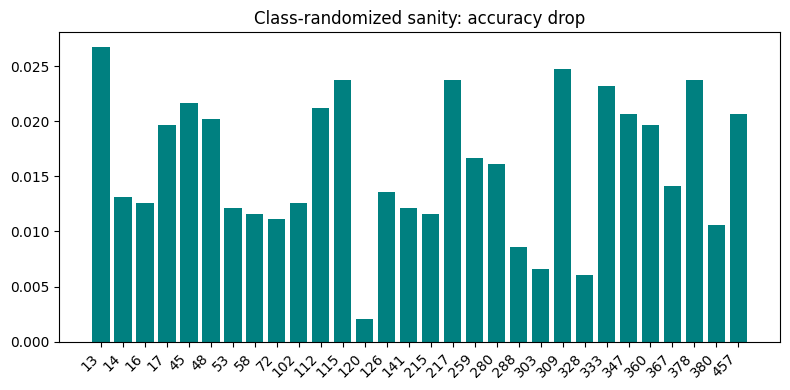


=== Class-Randomized Sanity: mean +/- std across seeds ===
  acc_correct_caption: 0.8217 +/- 0.0097  (n=30)
  acc_wrong_style_caption: 0.8057 +/- 0.0118  (n=30)
  accuracy_drop: 0.0160 +/- 0.0062  (n=30)
Saved summary: robustness\caption_evaluation\class_randomized_sanity\aggregation_mean_std.csv


In [12]:
class FusionRowDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, caption_col: str = "caption"):
        self.frame = frame.reset_index(drop=True)
        self.caption_col = caption_col

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return {"abs_path": row["abs_path"], "caption": str(row[self.caption_col]), "label": style_to_idx[row["style"]]}


class ClipBertFusionClassifier(nn.Module):
    def __init__(self, clip_model, clip_processor, bert_model, bert_tokenizer, num_classes, dropout=SANITY_DROPOUT):
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in list(self.clip_model.parameters()) + list(self.bert_model.parameters()):
            p.requires_grad = False
        vd = clip_model.config.projection_dim
        td = bert_model.config.hidden_size
        self.fusion = nn.Sequential(nn.Linear(vd + td, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_classes))

    def forward(self, pixel_values, captions):
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(captions, return_tensors="pt", padding=True, truncation=True, max_length=128).to(dev)
            textual = self.bert_model(**enc).last_hidden_state[:, 0, :].float()
        fused = self.fusion(torch.cat([visual, textual], dim=-1))
        return self.classifier(fused)


def collate_fusion(batch, clip_processor, device):
    # DataLoader default_collate: list[dict] -> dict of lists/tensors
    if isinstance(batch, dict):
        paths = list(batch["abs_path"])
        caps = list(batch["caption"])
        labels = batch["label"]
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
    else:
        paths = [b["abs_path"] for b in batch]
        caps = [b["caption"] for b in batch]
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    images = load_pil_batch(paths)
    px = clip_processor(images=images, return_tensors="pt")["pixel_values"].to(device)
    return px, caps, labels


def train_fusion_classifier(train_df, val_df, device):
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_ID).to(device)
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    model = ClipBertFusionClassifier(clip_model, clip_processor, bert_model, bert_tokenizer, num_classes).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=SANITY_LR)
    crit = nn.CrossEntropyLoss()
    train_loader = DataLoader(FusionRowDataset(train_df), batch_size=SANITY_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FusionRowDataset(val_df), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    best_f1, best_state = -1.0, None
    for epoch in range(SANITY_TRAIN_EPOCHS):
        model.train()
        for batch in train_loader:
            px, caps, y = collate_fusion(batch, clip_processor, device)
            opt.zero_grad()
            logits = model(px, caps)
            loss = crit(logits, y.to(device))
            loss.backward()
            opt.step()
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                px, caps, y = collate_fusion(batch, clip_processor, device)
                preds.extend(model(px, caps).argmax(1).cpu().tolist())
                labels.extend(y.tolist())
        vf1 = f1_score(labels, preds, average="macro", zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model, clip_processor


@torch.no_grad()
def eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption"):
    loader = DataLoader(FusionRowDataset(test_df, caption_col=caption_col), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    preds, labels = [], []
    model.eval()
    for batch in loader:
        px, caps, y = collate_fusion(batch, clip_processor, device)
        preds.extend(model(px, caps).argmax(1).cpu().tolist())
        labels.extend(y.tolist())
    return accuracy_score(labels, preds)


def run_class_randomized_sanity():
    out_dir = metric_dir("class_randomized_sanity")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        train_df, val_df, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        model, clip_processor = train_fusion_classifier(train_df, val_df, device)
        acc_correct = eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption")
        wrong = test_df.copy()
        rng = np.random.default_rng(CLASS_RANDOM_SANITY_SEED + seed)
        wrong_caps = []
        for _, row in wrong.iterrows():
            candidates = df_full[df_full["style"] != row["style"]]["caption"].values
            wrong_caps.append(rng.choice(candidates))
        wrong["caption_wrong_style"] = wrong_caps
        acc_wrong = eval_fusion_accuracy(model, clip_processor, wrong, device, caption_col="caption_wrong_style")
        drop = acc_correct - acc_wrong
        print(f"[class_sanity] {seed_tag} ({si}/{len(SEEDS)}): correct={acc_correct:.4f} wrong_style={acc_wrong:.4f} drop={drop:.4f}")
        rows.append({"seed": seed, "acc_correct_caption": acc_correct, "acc_wrong_style_caption": acc_wrong, "accuracy_drop": drop})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["accuracy_drop"], color="teal")
    ax.set_title("Class-randomized sanity: accuracy drop")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "class_randomized_drop_per_seed.png", dpi=150)
    plt.show()
    return summary_df

class_sanity_summary = run_class_randomized_sanity()
save_summary_csv(
    print_mean_std_table(class_sanity_summary, ["acc_correct_caption", "acc_wrong_style_caption", "accuracy_drop"], "Class-Randomized Sanity"),
    metric_dir("class_randomized_sanity") / "aggregation_mean_std.csv",
)

## 5. Global cross-metric summary

Collect per-metric aggregation CSVs into one table.


In [13]:
def load_agg(metric_name: str) -> pd.DataFrame:
    p = metric_dir(metric_name) / "aggregation_mean_std.csv"
    if p.is_file():
        df = pd.read_csv(p)
        df.insert(0, "metric_group", metric_name)
        return df
    return pd.DataFrame()

parts = [
    load_agg("clip_similarity"),
    load_agg("clip_iqa"),
    load_agg("blipscore"),
    load_agg("retrieval_recall"),
    load_agg("confusion_matrix"),
    load_agg("gpt4o_evaluation"),
    load_agg("random_caption_sanity"),
    load_agg("class_randomized_sanity"),
]
global_summary = pd.concat([p for p in parts if len(p)], ignore_index=True)
global_path = RESULTS_ROOT / "global_aggregation_mean_std.csv"
global_summary.to_csv(global_path, index=False)
print("Global aggregation saved:", global_path)
print(global_summary.to_string(index=False))

Global aggregation saved: robustness\caption_evaluation\global_aggregation_mean_std.csv
           metric_group                  metric     mean      std
        clip_similarity    clip_similarity_mean 0.299966 0.000524
               clip_iqa       clip_iqa_win_rate 0.937538 0.007296
               clip_iqa    clip_iqa_margin_mean 0.094218 0.000695
              blipscore           blip_itm_mean 0.919354 0.003035
       retrieval_recall            i2t_recall@1 0.248049 0.008934
       retrieval_recall            i2t_recall@5 0.495661 0.009779
       retrieval_recall           i2t_recall@10 0.609233 0.009907
       retrieval_recall            t2i_recall@1 0.199025 0.010839
       retrieval_recall            t2i_recall@5 0.406307 0.013906
       retrieval_recall           t2i_recall@10 0.514194 0.012464
       confusion_matrix                accuracy 0.270686 0.004684
       confusion_matrix                macro_f1 0.211567 0.004659
       gpt4o_evaluation     gpt4o_semantic_mean 4.0428